# DICOM files reading and visualization tutorial
In this tutorial you will familiarize yourself with DICOM, the most common format used for transferring and storing medical images.
Your task will be to read a couple of MR sequencues, and visualize them correctly

## Imports
You will read dicom files using the dcmread module from pydicom
numpy to handle data arrays
glob to parse the data files
matplotlib.pyplot to visualize

In [2]:
from pydicom import dcmread
import pydicom.errors
import numpy as np
import glob
import matplotlib.pyplot as plt

## Read all the files in a directory

Dicom stores (generally) every "sequence" in a directory, with one file per slice. You need to iterate over all of them to reconstruct a volume.
dcmread returns a structure containing multiple information concerning each file, including all the header.

1. Find all the files in DICOM subdirectory and read them using dcmread(filename), store them in a list. You can use glob
2. Can you read all of them? If not why? Hint: if a non-dicom file is present dcmread raises this error: pydicom.errors.InvalidDicomError
3. Parse trough the header of the first slice. Find the patient name, birthdate, weight

In [3]:
fileDir = glob.glob('DICOM/*')

In [4]:
fileDir

['DICOM\\desktop.ini',
 'DICOM\\I0',
 'DICOM\\I1',
 'DICOM\\I10',
 'DICOM\\I100',
 'DICOM\\I101',
 'DICOM\\I102',
 'DICOM\\I103',
 'DICOM\\I104',
 'DICOM\\I105',
 'DICOM\\I106',
 'DICOM\\I107',
 'DICOM\\I108',
 'DICOM\\I109',
 'DICOM\\I11',
 'DICOM\\I110',
 'DICOM\\I111',
 'DICOM\\I112',
 'DICOM\\I113',
 'DICOM\\I114',
 'DICOM\\I115',
 'DICOM\\I116',
 'DICOM\\I117',
 'DICOM\\I118',
 'DICOM\\I119',
 'DICOM\\I12',
 'DICOM\\I120',
 'DICOM\\I121',
 'DICOM\\I122',
 'DICOM\\I123',
 'DICOM\\I124',
 'DICOM\\I125',
 'DICOM\\I126',
 'DICOM\\I127',
 'DICOM\\I128',
 'DICOM\\I129',
 'DICOM\\I13',
 'DICOM\\I130',
 'DICOM\\I131',
 'DICOM\\I132',
 'DICOM\\I133',
 'DICOM\\I134',
 'DICOM\\I135',
 'DICOM\\I136',
 'DICOM\\I137',
 'DICOM\\I138',
 'DICOM\\I139',
 'DICOM\\I14',
 'DICOM\\I140',
 'DICOM\\I141',
 'DICOM\\I142',
 'DICOM\\I143',
 'DICOM\\I144',
 'DICOM\\I145',
 'DICOM\\I146',
 'DICOM\\I147',
 'DICOM\\I148',
 'DICOM\\I149',
 'DICOM\\I15',
 'DICOM\\I150',
 'DICOM\\I151',
 'DICOM\\I152',
 'DICOM\\I1

In [5]:
files = []
for fname in fileDir:
    try:
        files.append(dcmread(fname))
    except pydicom.errors.InvalidDicomError:
        print (fname + ' is not dicom')
        

DICOM\desktop.ini is not dicom


In [6]:
files[0].PatientWeight

'80.0'

In [7]:
files[0]

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 224
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.5962.99.1.3065098865.1601133648.1678102377073.246.0
(0002, 0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.3.6.1.4.1.5962.99.2
(0002, 0013) Implementation Version Name         SH: 'PIXELMEDJAVA001'
(0002, 0016) Source Application Entity Title     AE: 'DIP1851_11112'
-------------------------------------------------
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008, 0012) Instance Creation Date              DA: '20150624'
(0008, 0013) Instance Creation Time              TM: '113404'
(0008, 0016) SOP Class UID                       UI: CT Image Storage
(0008, 0018) SO

## Order the slices and build a volume

1. Each dicom file has a field called "SliceLocation". As you cannot trust the idea that files are in the correct order to be stacked, you need to stack them after sorting them using the SliceLocation.

2. Declare an empty numpy array to be filled. Each file is a 2D matrix, with dimensions written in the pixel_array.shape property. The n° of slices is the numer of files.

3. Fill the volume by looping over each slice, and storing this 2D matrix in the 3D array (.pixel_array property)


In [8]:
files = sorted(files, key=lambda s: s.SliceLocation)

In [9]:
img_shape = list(files[0].pixel_array.shape)
img_shape.append(len(files))
img3d = np.zeros(img_shape)

In [9]:
for i, s in enumerate(files):
    img2d = s.pixel_array
    img3d[:, :, i] = img2d*s.RescaleSlope+s.RescaleIntercept

In [11]:
s.RescaleIntercept

'-1024.0'

## Display slices of the volume

Display three different planes of the volume

In [12]:
img3d.shape

(512, 512, 313)

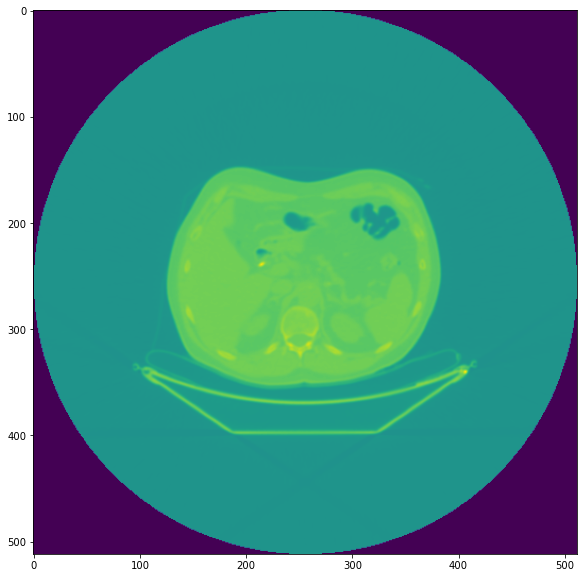

In [10]:
plt.figure(figsize=(10,10))
_=plt.imshow(img3d[:,:,img_shape[-1]//2]) #,cmap='gray',vmin=-1024,vmax=0)

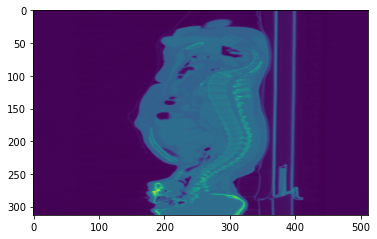

In [11]:
_=plt.imshow(img3d[:,img_shape[1]//2,:].T)

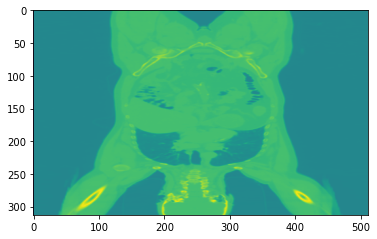

In [13]:
_=plt.imshow(img3d[img_shape[0]//2,:,:].T)

**Take a look at the results**

Do all three images look good? Is the default colormap good for MR? Are the images flipped correctly?

Try again a better display, taking into account that images have different pixel sizes over the three axes. Specifically, the pixel of the 2D matrix have sized described in the property PixelSpacing , while the slices are spaced by SliceThickness

In matplotlib you can set the aspect ratio by doing 

        a1 = plt.subplot(2,2,1)
        plt.imshow(imm)
        a1.set_aspect(pixelSizeY/pixelSizeX)
Note that you need to put the X axis in the numerator and the Y in the denominator, as matplotlib transposes the axes!!

Note that coordinates, flips, orientation etc... are all described in dicom headers, but this is not a core topic of the course.

In [32]:
files[0].SliceThickness

'3.75'

In [13]:
files[0].PixelSpacing

[1.367188, 1.367188]

In [13]:
ps = files[0].PixelSpacing
ss = files[0].SliceThickness
ax_aspect = ps[0]/ps[1]
sag_aspect = ps[1]/ss
cor_aspect = ss/ps[0]

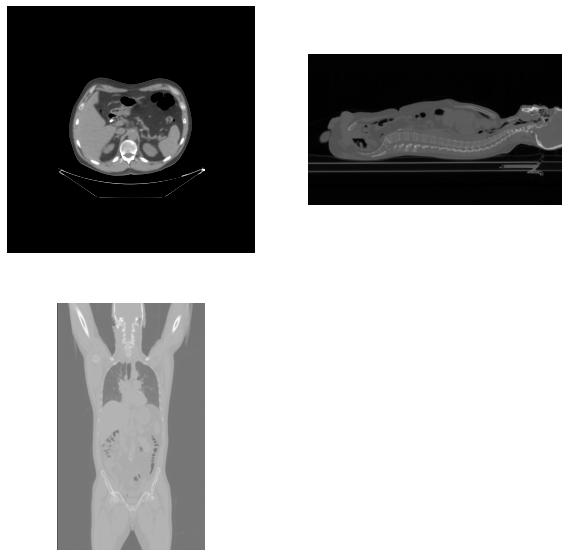

In [39]:
plt.figure(figsize=(10,10))
a1 = plt.subplot(2, 2, 1)
plt.imshow(img3d[:, :, img_shape[2]//2],cmap='gray',vmin=-220,vmax=240)
a1.set_aspect(ax_aspect)
#plt.colorbar()
plt.axis('off')
a2 = plt.subplot(2, 2, 2)
plt.imshow(img3d[:, img_shape[1]//2, :],cmap='gray')
a2.set_aspect(sag_aspect)
plt.axis('off')
a3 = plt.subplot(2, 2, 3)
plt.imshow(np.flip(img3d[img_shape[0]//2, :, :].T,axis=0),cmap='gray')
a3.set_aspect(cor_aspect)

plt.axis('off')
plt.show()

# Multiple possible windows
As 

(-0.5, 299.5, 249.5, -0.5)

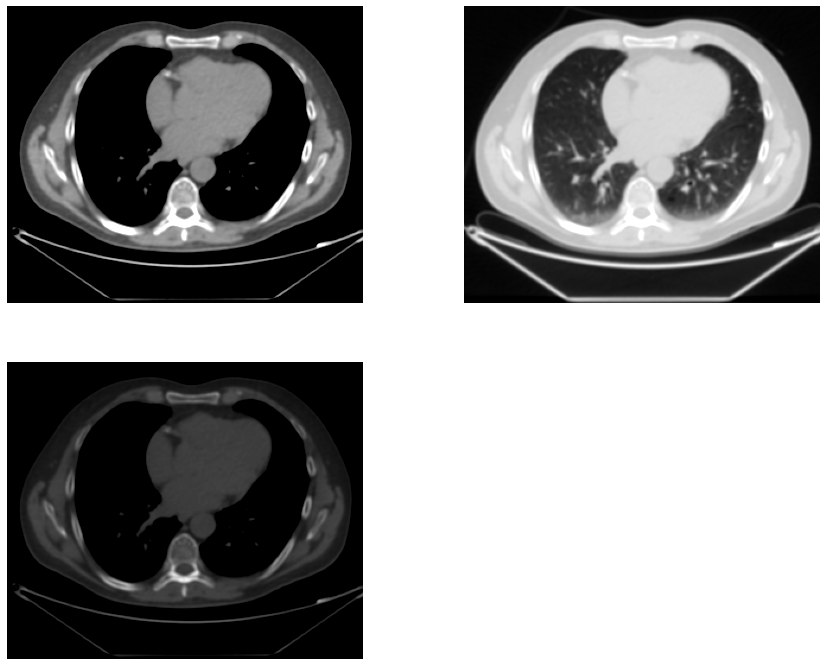

In [30]:
plt.figure(figsize=(15,12))
plt.subplot(221)
plt.imshow(img3d[150:400,100:400, -120],cmap='gray',vmin=-220,vmax=240)
plt.axis('off')
plt.subplot(222)
plt.imshow(img3d[150:400,100:400, -120],cmap='gray',vmin=-1024,vmax=240)
plt.axis('off')
plt.subplot(223)
plt.imshow(img3d[150:400,100:400, -120],cmap='gray',vmin=-200,vmax=800)
plt.axis('off')

In [25]:
imgRedS = img3d[::3,::3,::3]

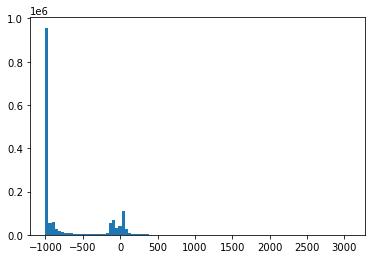

In [26]:
_=plt.hist(imgRedS[imgRedS>-1000].flat,100)